In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# df = pd.read_csv("../data/insurance_data.csv")
df = pd.read_csv("../data/insurance_data.csv", 
                 sep="|", 
                 low_memory=False,
                 engine="python")
df.columns = df.columns.str.strip()

In [4]:
df.head()

df.info()

df.describe()

df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

(1000098, 52)

In [5]:
df.isnull().sum().sort_values(ascending=False)

NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
CustomValueEstimate          779642
Rebuilt                      641901
Converted                    641901
WrittenOff                   641901
NewVehicle                   153295
Bank                         145961
AccountType                   40232
Gender                         9536
MaritalStatus                  8259
VehicleType                     552
make                            552
mmcode                          552
Model                           552
Cylinders                       552
bodytype                        552
kilowatts                       552
NumberOfDoors                   552
VehicleIntroDate                552
cubiccapacity                   552
CapitalOutstanding                2
SubCrestaZone                     0
ItemType                          0
Province                          0
Country                           0
PostalCode                        0
MainCrestaZone              

In [6]:
df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='str')

In [7]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

<Axes: xlabel='TotalClaims', ylabel='Count'>

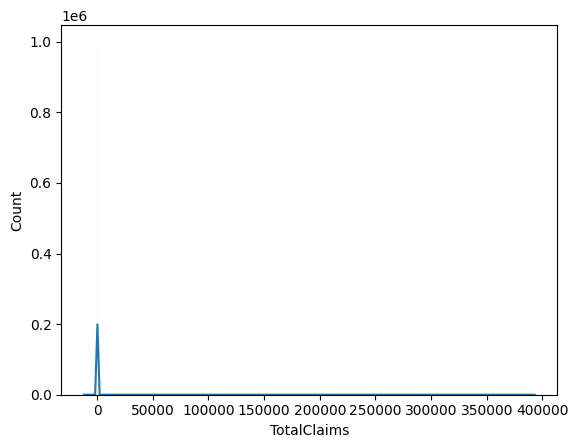

In [8]:
sns.histplot(df["TotalClaims"], kde=True)

<Axes: xlabel='Gender'>

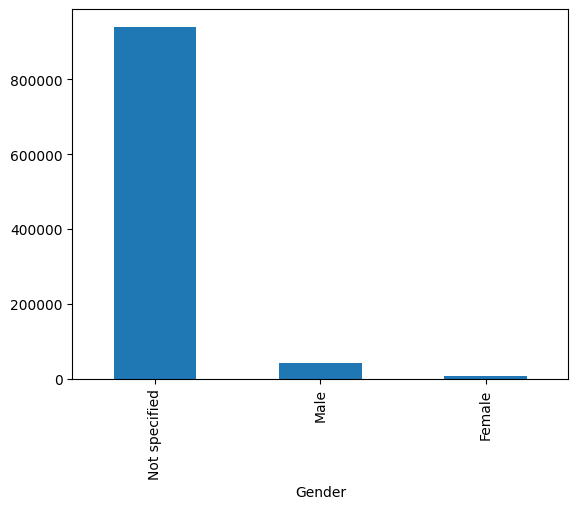

In [9]:
df["Gender"].value_counts().plot(kind="bar")

<Axes: >

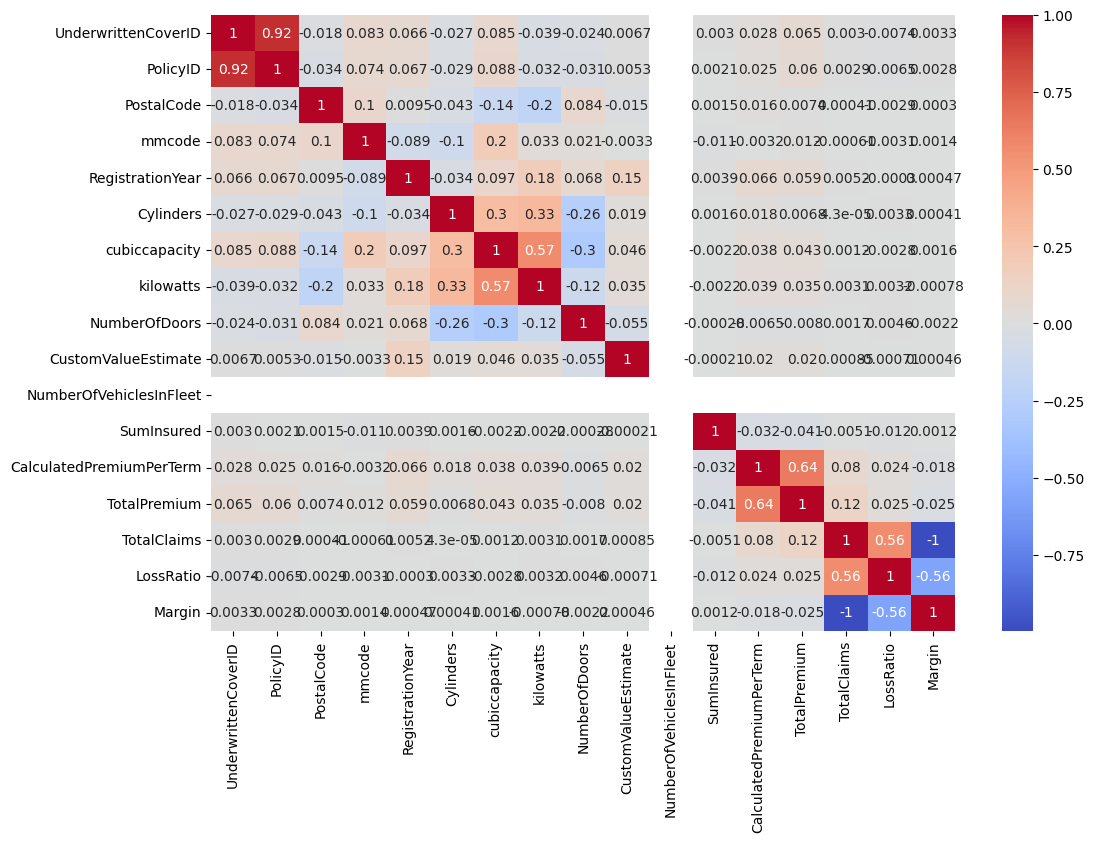

In [10]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

<Axes: xlabel='TotalPremium', ylabel='TotalClaims'>

c:\insurance-risk-analytics\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\insurance-risk-analytics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


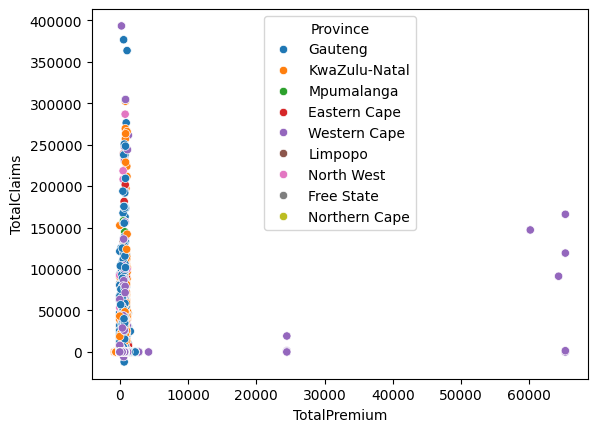

In [11]:
sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    hue="Province"
)

<Axes: xlabel='Province'>

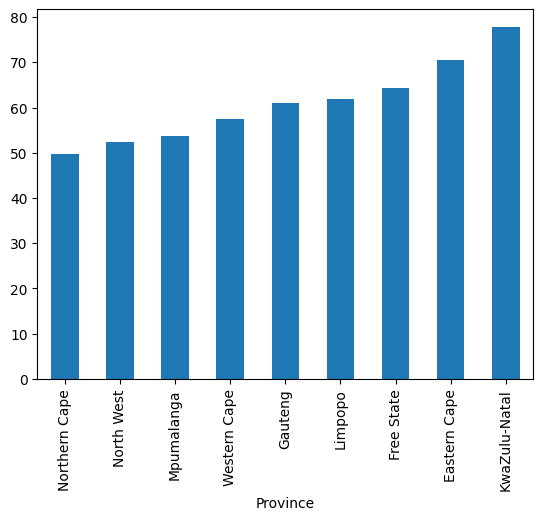

In [12]:
province_premium = df.groupby("Province")["TotalPremium"].mean()

province_premium.sort_values().plot(kind="bar")

In [13]:
province_claims = df.groupby("Province")["TotalClaims"].mean()

<Axes: xlabel='TotalClaims'>

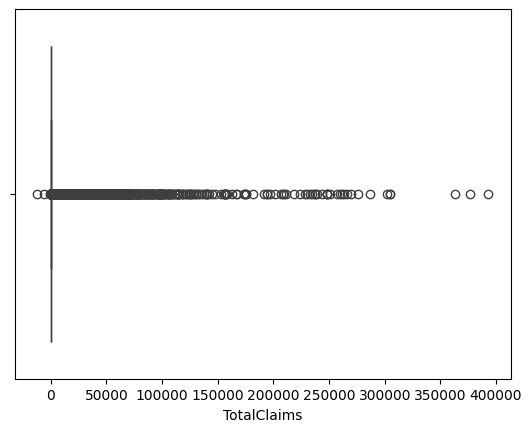

In [14]:
sns.boxplot(x=df["TotalClaims"])

In [15]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

<Axes: xlabel='TransactionMonth'>

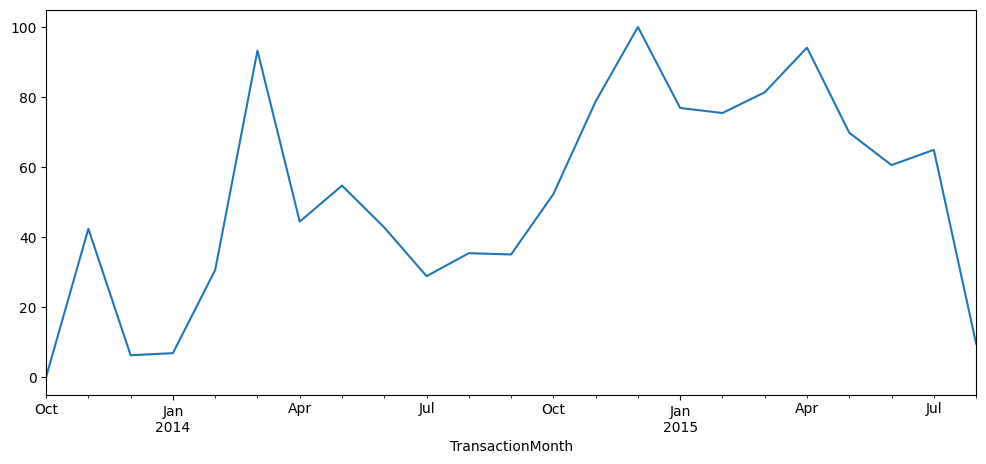

In [16]:
monthly_claims = df.groupby("TransactionMonth")["TotalClaims"].mean()

monthly_claims.plot(figsize=(12,5))

In [17]:
# df["LossRatio"].mean()
# df.groupby("Make")["TotalClaims"].mean().sort_values()

df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    np.nan
)



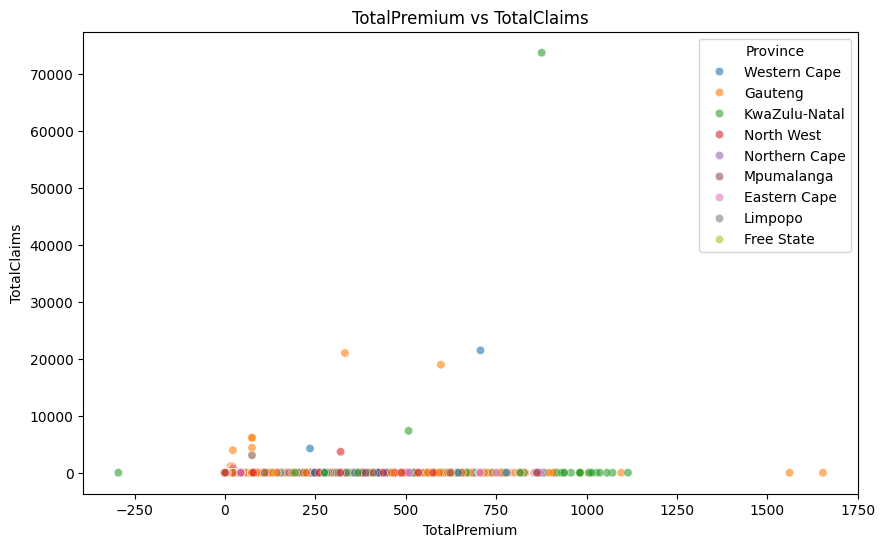

In [18]:
sample_df = df.sample(5000)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="TotalPremium",
    y="TotalClaims",
    hue="Province",
    alpha=0.6
)

plt.title("TotalPremium vs TotalClaims")
plt.show()

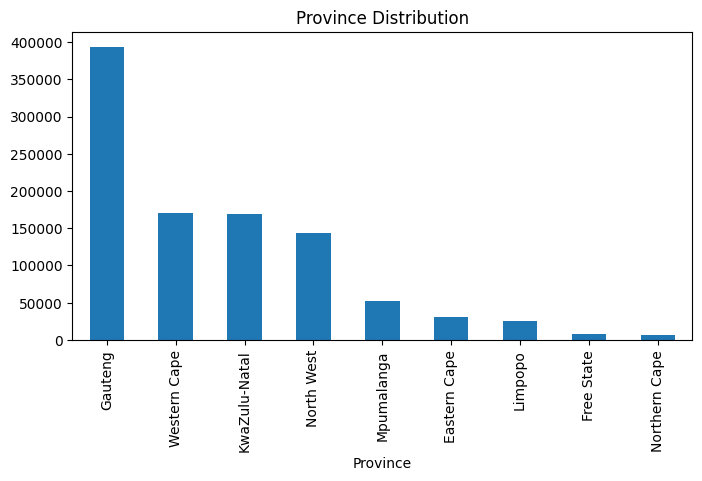

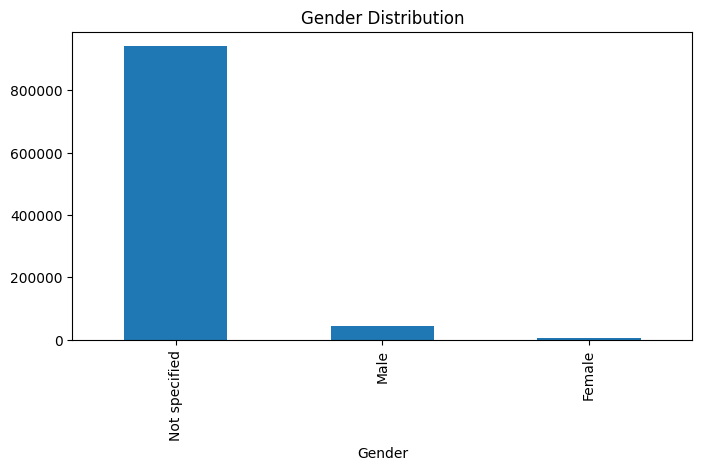

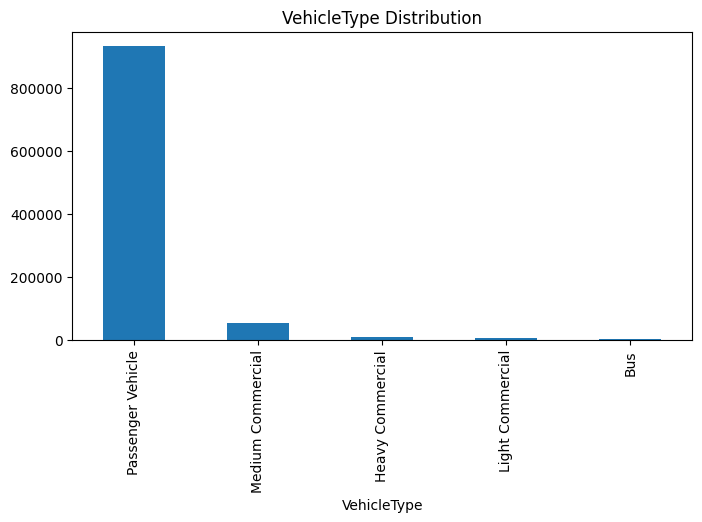

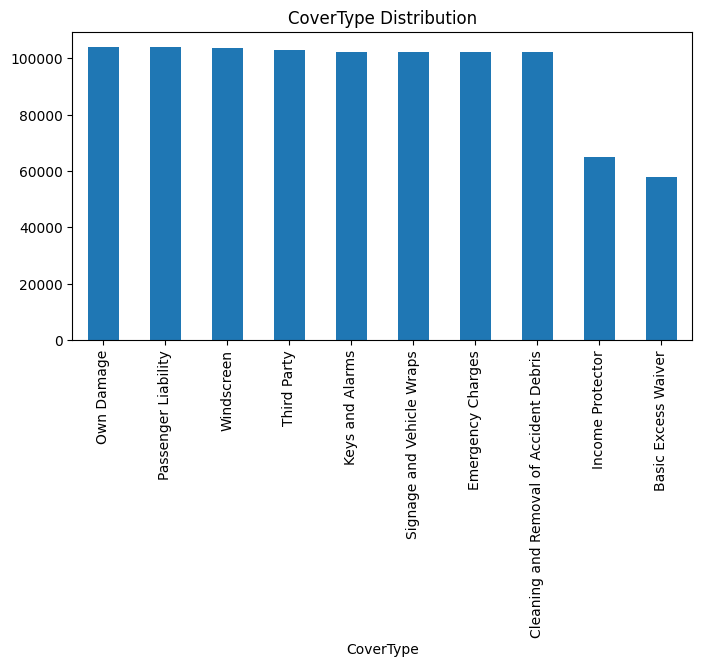

In [19]:
categorical_cols = [
    "Province",
    "Gender",
    "VehicleType",
    "CoverType"
]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"{col} Distribution")
    plt.show()

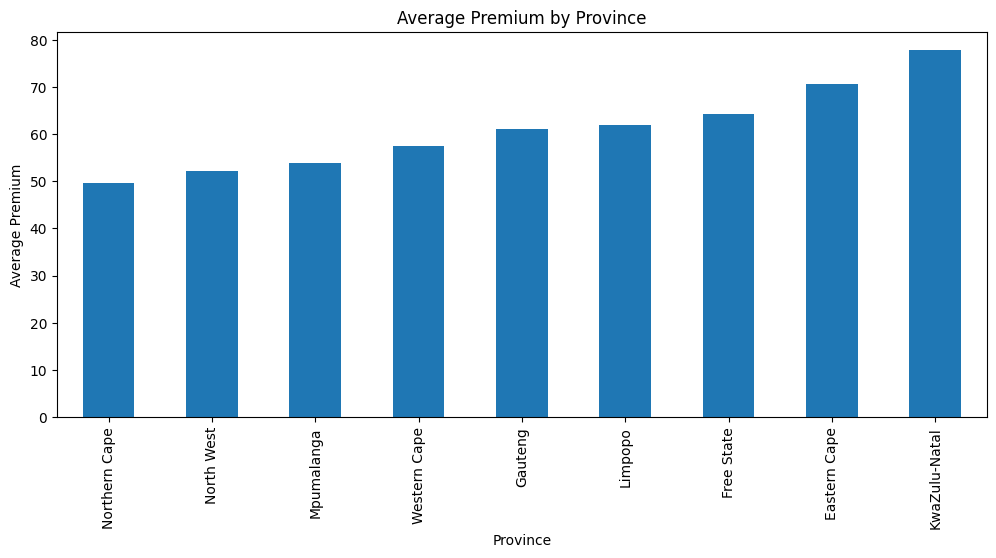

In [20]:
province_premium = (
    df.groupby("Province")["TotalPremium"]
    .mean()
    .sort_values()
)

province_premium.plot(
    kind="bar",
    figsize=(12,5),
    title="Average Premium by Province"
)

plt.ylabel("Average Premium")
plt.show()

In [21]:
top_makes = (
    df.groupby(["Province", "make"])
    .size()
    .reset_index(name="count")
)

top_makes.sort_values("count", ascending=False).head(10)

,Province,make,count
59,Gauteng,TOYOTA,306045
80,KwaZulu-Natal,TOYOTA,153241
177,Western Cape,TOYOTA,148218
140,North West,TOYOTA,108035
110,Mpumalanga,TOYOTA,41589
12,Eastern Cape,TOYOTA,26582
95,Limpopo,TOYOTA,18076
48,Gauteng,MERCEDES-BENZ,17916
36,Gauteng,GOLDEN JOURNEY,12008
31,Gauteng,CMC,9141


In [22]:
overall_loss_ratio = df["LossRatio"].mean()

overall_loss_ratio

np.float64(0.3500476647582784)

In [23]:
df.groupby("Province")["LossRatio"].mean()

Province
Eastern Cape     0.235636
Free State       0.106209
Gauteng          0.428927
KwaZulu-Natal    0.265328
Limpopo          0.348712
Mpumalanga       0.392698
North West       0.285348
Northern Cape    0.203831
Western Cape     0.341810
Name: LossRatio, dtype: float64

In [24]:
# df.groupby("VehicleType")["LossRatio"].mean()
df.groupby("VehicleType")["LossRatio"].mean().sort_values(ascending=False)

VehicleType
Heavy Commercial     0.793617
Light Commercial     0.543917
Medium Commercial    0.493386
Passenger Vehicle    0.337534
Bus                  0.000000
Name: LossRatio, dtype: float64

In [25]:
df.groupby("Gender")["LossRatio"].mean().sort_values(ascending=False)

Gender
Female           0.491979
Male             0.353258
Not specified    0.347932
Name: LossRatio, dtype: float64

In [26]:
cleaned_df = df.copy()

# remove duplicates
cleaned_df = cleaned_df.drop_duplicates()

# handle missing values
cleaned_df["TotalPremium"] = cleaned_df["TotalPremium"].fillna(
    cleaned_df["TotalPremium"].median()
)

cleaned_df["TotalClaims"] = cleaned_df["TotalClaims"].fillna(0)

# save cleaned version
cleaned_df.to_csv("../data/insurance_data_cleaned.csv", index=False)